In [49]:
#TASK 1: Data Collection & Understanding


In [2]:
import pandas as pd

data = pd.read_csv("netflix_titles.csv", encoding='latin1')

data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Structure
print("Shape:", data.shape)
print("Columns:", data.columns)
data.info()

Shape: (8807, 12)
Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [51]:
#TASK 2: Data Cleaning & Feature Engineering

In [4]:
# Remove extra spaces and standardize column names
data.columns = data.columns.str.strip().str.replace(" ", "_")

print(data.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [5]:
#Check Missing Values
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
# Handle Missing Data (clean + warning-free)

data.fillna({
    'director': "Unknown",
    'cast': "Unknown",
    'country': "Unknown"
}, inplace=True)

# Drop rows with missing rating
data.dropna(subset=['rating'], inplace=True)

In [9]:
data.drop_duplicates(inplace=True)

In [15]:
# Extract year added
data['year_added'] = pd.to_datetime(data['date_added'], errors='coerce').dt.year

In [18]:
# Convert duration to numeric (extract numbers safely)
data['duration'] = pd.to_numeric(
    data['duration'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)

In [19]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90.0,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2.0,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1.0,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1.0,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2.0,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [52]:
#TASK 3: Exploratory Data Analysis (EDA)

In [20]:
data.describe()

,release_year,duration,year_added
count,8803.000000,8800.000000,8705.000000
mean,2014.179825,69.861136,2018.888800
std,8.821247,50.812288,1.567725
min,1925.000000,1.000000,2008.000000
25%,2013.000000,2.000000,2018.000000
50%,2017.000000,88.000000,2019.000000
75%,2019.000000,106.000000,2020.000000
max,2021.000000,312.000000,2021.000000


In [21]:
#Content Type Distribution
data['type'].value_counts()

type
Movie      6129
TV Show    2674
Name: count, dtype: int64

In [22]:
#Top Countries
data['country'].value_counts().head(10)

country
United States     2818
India              972
Unknown            830
United Kingdom     419
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [23]:
#Release Year Trends
data['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1031
2019    1030
2020     953
2016     902
2021     592
2015     558
2014     352
2013     287
2012     237
Name: count, dtype: int64

In [37]:
#Age Analysis
data['Age'].describe()

count    891.000000
mean      29.561167
std       14.567604
min        0.000000
25%       20.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [24]:
#Ratings Analysis
data['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [ ]:
#TASK 4: Data Visualization

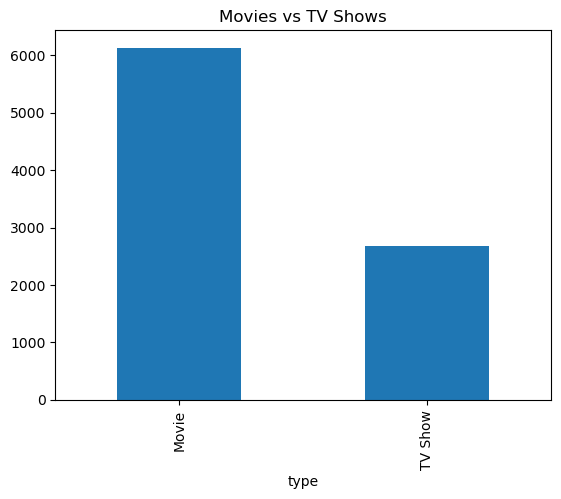

In [25]:
import matplotlib.pyplot as plt

#Movies vs TV Shows
data['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

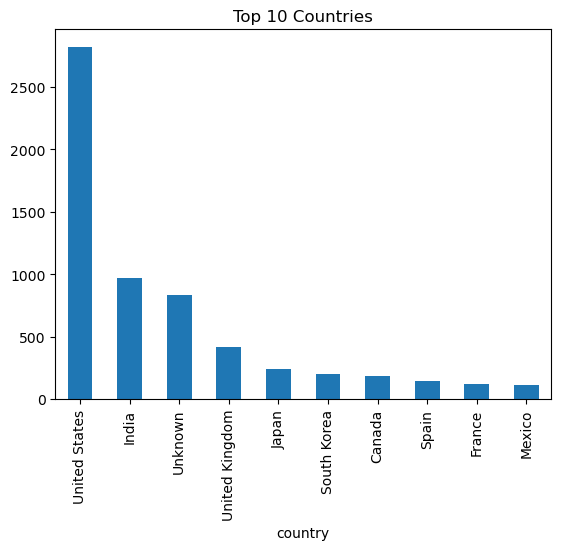

In [26]:
#Top Countries
data['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

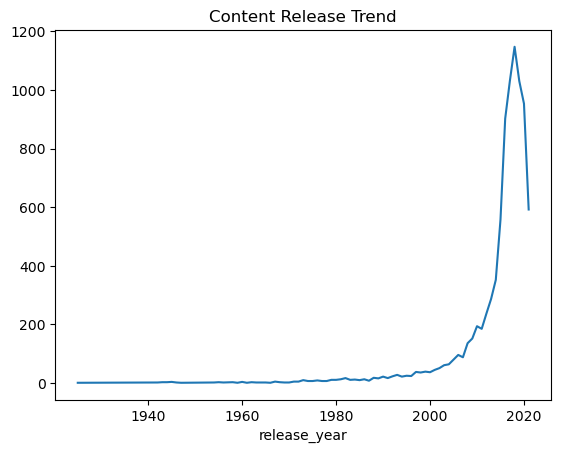

In [27]:
#Release Trend
data['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend")
plt.show()

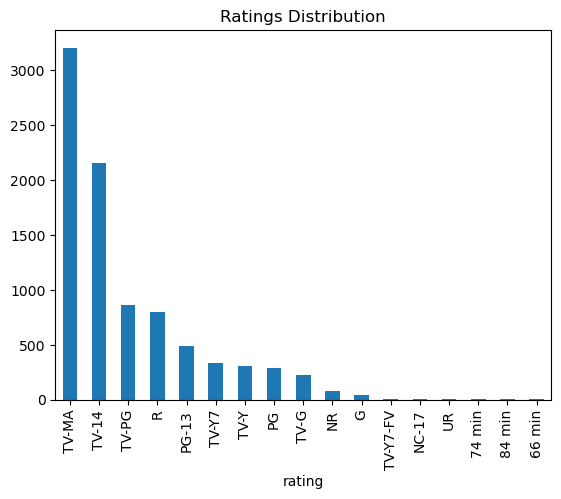

In [28]:
#Ratings Distribution
data['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution")
plt.show()

In [ ]:
#TASK 5: Predictive Modeling 

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [73]:
data = data.copy()

# clean text
data['type'] = data['type'].astype(str).str.lower().str.strip()

# JUGAAR: fix common variations automatically
data['type'] = data['type'].replace({
    'tv show': 'tv show',
    'tv show ': 'tv show',
    'movie': 'movie',
    'movie ': 'movie'
})

# NOW convert safely
data = data[data['type'].isin(['movie', 'tv show'])]

data['type'] = data['type'].map({'movie': 0, 'tv show': 1})

In [74]:
# If dataset accidentally becomes empty, rollback safely
if data.shape[0] == 0:
    data = data.copy()
    data = data.dropna(subset=['type'])

In [75]:
X = data[['release_year', 'duration']].copy()

# extract numbers safely
X['duration'] = X['duration'].astype(str).str.extract('(\d+)')

# convert errors to NaN → then fill
X['duration'] = pd.to_numeric(X['duration'], errors='coerce')

# fill missing values (important jugaar)
X['duration'] = X['duration'].fillna(X['duration'].median())
X['release_year'] = X['release_year'].fillna(X['release_year'].median())

In [76]:
y = data['type']

In [77]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (0, 2)
y shape: (0,)
Series([], Name: count, dtype: int64)


In [78]:
y = data['type']X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

SyntaxError: invalid syntax (3778319863.py, line 1)

In [68]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print(data['type'].value_counts())

X shape: (0, 2)
y shape: (0,)
Series([], Name: count, dtype: int64)
